In [1]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

Input = [('scale',StandardScaler()), ('polynomial', PolynomialFeatures(degree=3)), ('model', LinearRegression())]

path = r"Final_Data.csv"
df = pd.read_csv(path)
df = df[::50]

X = df[[
 'TGS2602-1',
 'TGS2602-2',
 'TGS2600-1',
 'TGS2600-2',
 'TGS2610-1',
 'TGS2610-2',
 'TGS2620-1',
 'TGS2620-2',
 'TGS2602-3',
 'TGS2602-4',
 'TGS2600-3',
 'TGS2600-4',
 'TGS2610-3',
 'TGS2610-4',
 'TGS2620-3',
 'TGS2620-4']]

Y = df[['Ethylene con: (ppm)']]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

pipe = Pipeline(Input)

pipe.fit(X_train, Y_train)
yhat = pipe.predict(X_test)
print(yhat)


[[1.92709981]
 [1.88318332]
 [2.77476795]
 ...
 [1.91974123]
 [2.28760585]
 [2.09080217]]


C:\Users\Manjunadh\AppData\Local\Temp\ipykernel_3140\531947032.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(Y_test, hist = False, color = 'b', label = "Actual Value")
C:\Users\Manjunadh\AppData\Local\Temp\ipykernel_3140\531947032.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

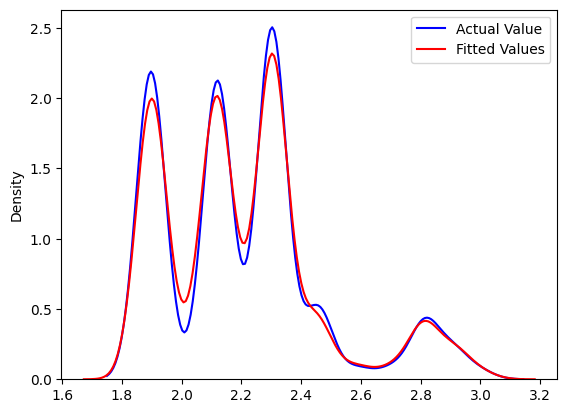

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt  # Import for legend

ax1 = sns.distplot(Y_test, hist = False, color = 'b', label = "Actual Value")
sns.distplot(yhat, hist=False, color = "r", label = "Fitted Values", ax = ax1)
plt.legend()  
plt.show()  


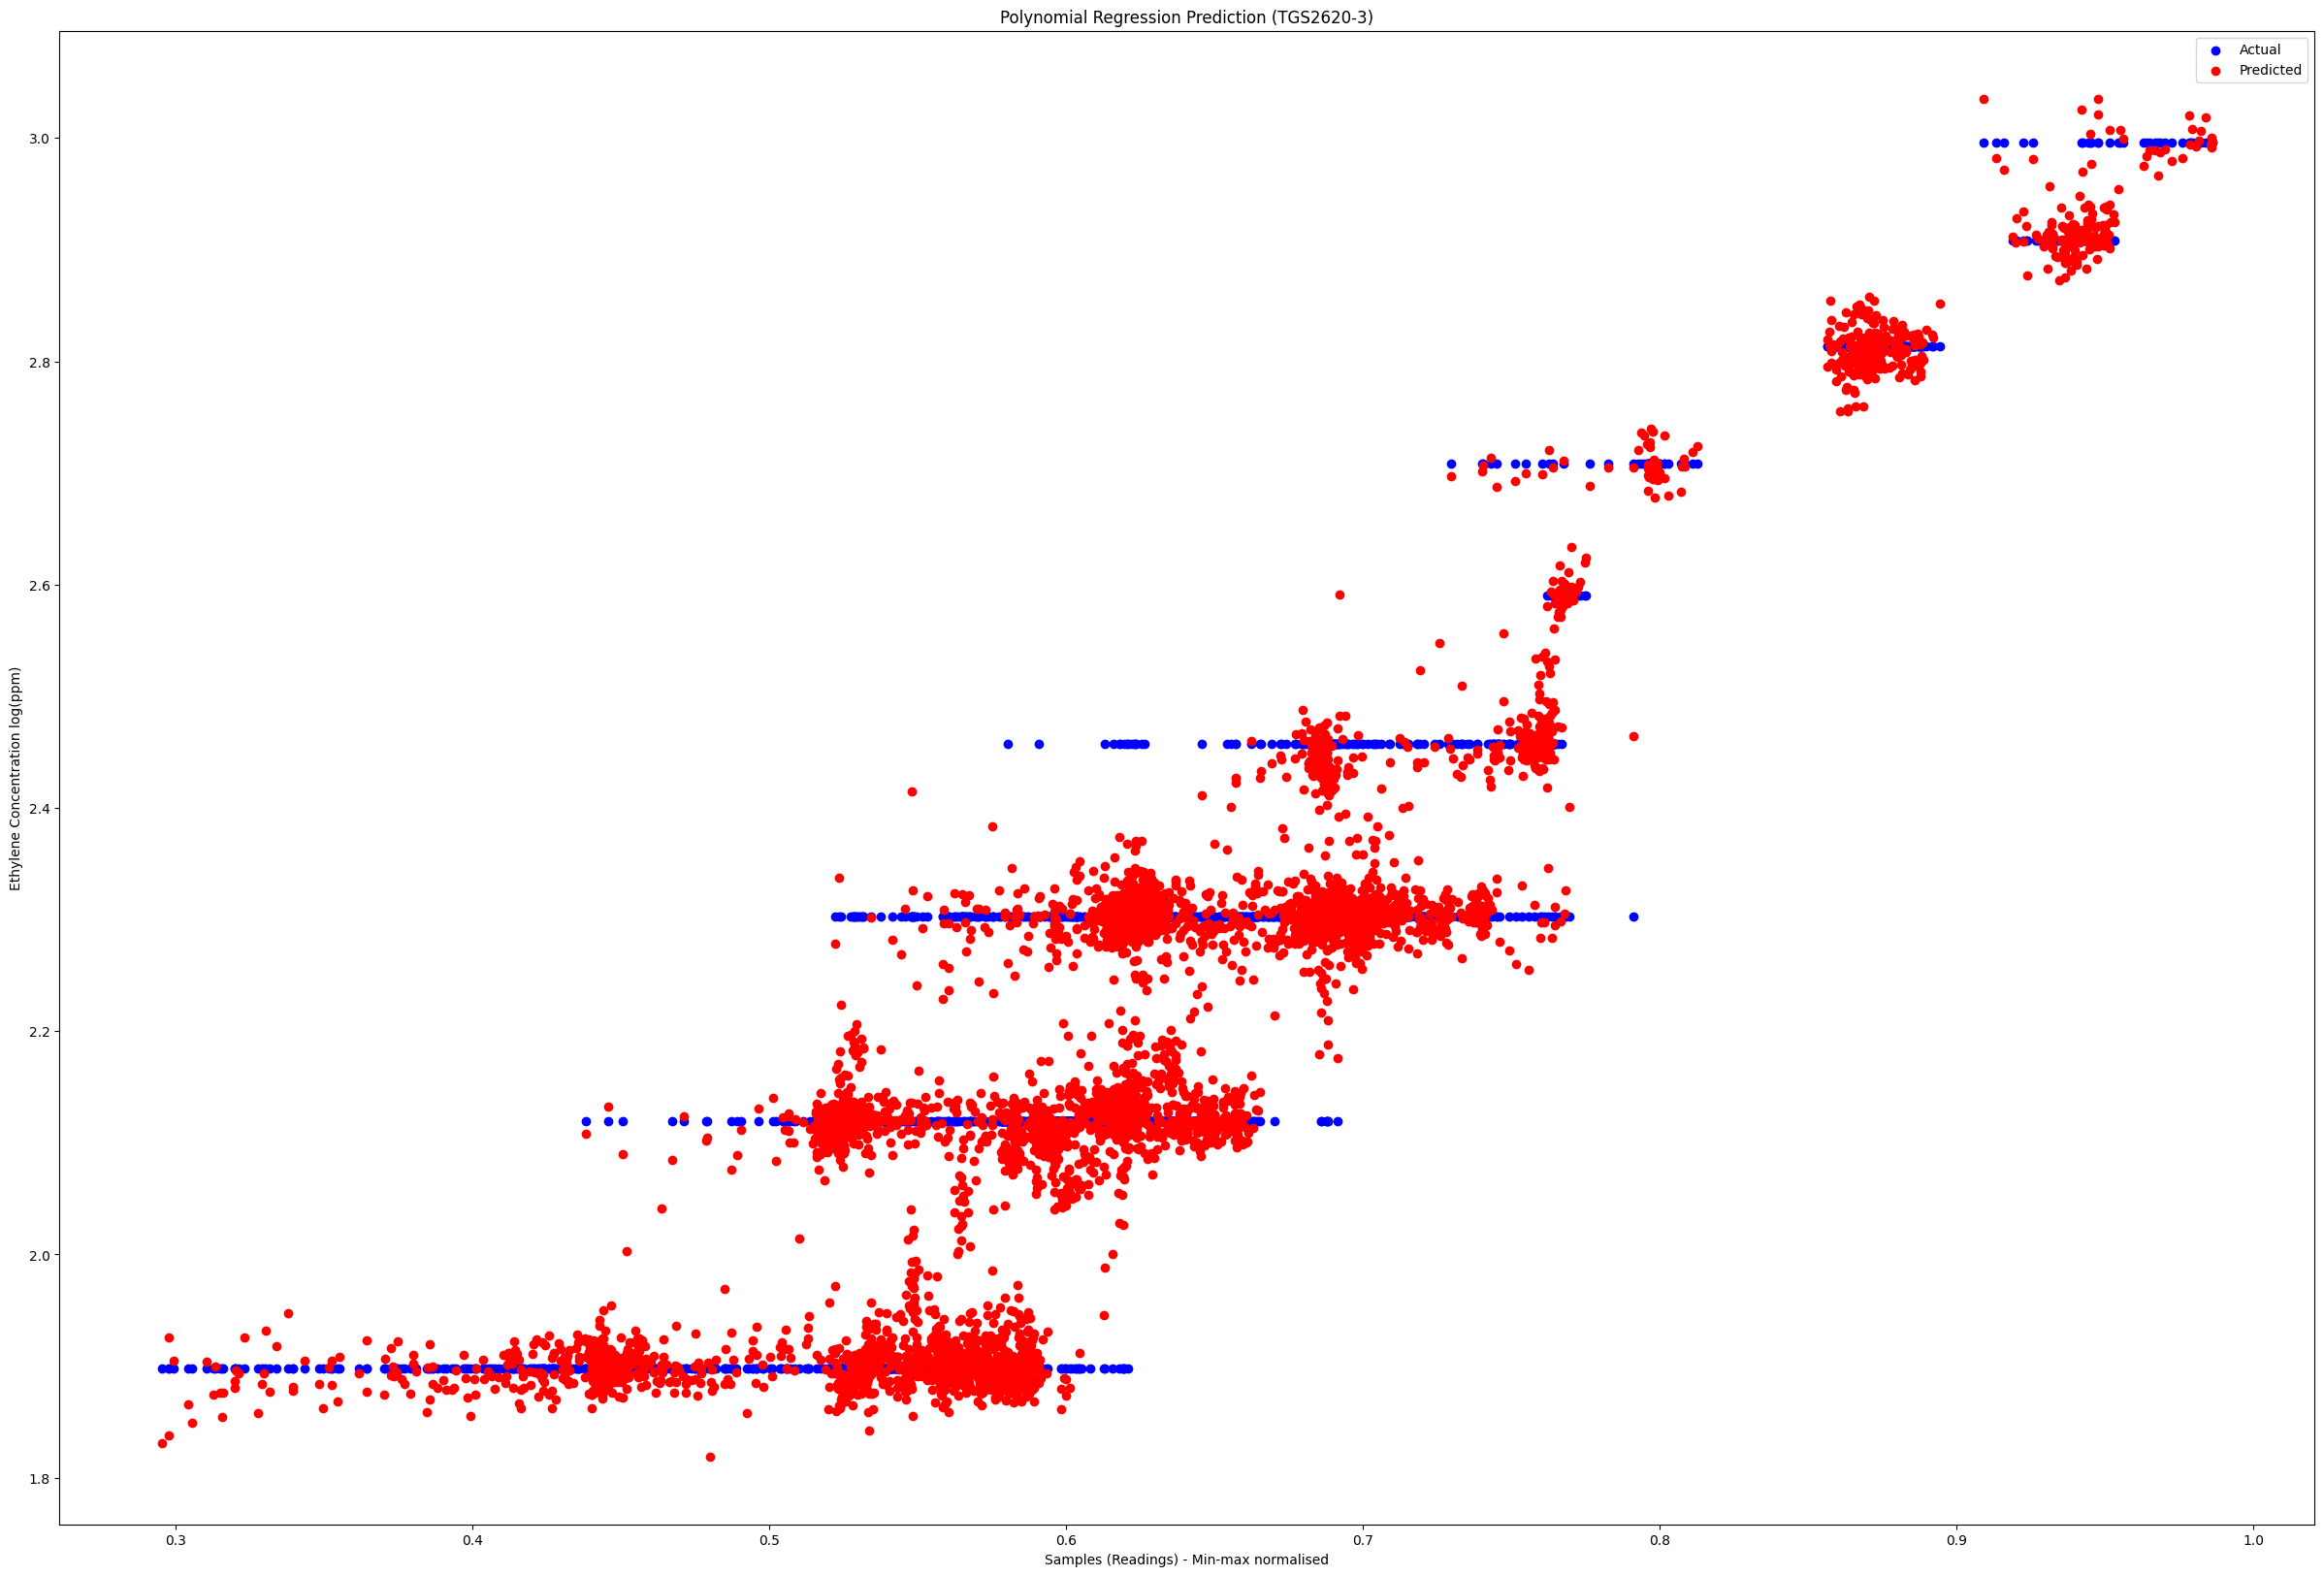

In [3]:
import matplotlib.pyplot as plt

# Plotting the predicted values
plt.figure(figsize=(30, 20))
plt.scatter(X_test['TGS2620-3'], Y_test, color='blue', label='Actual')
plt.scatter(X_test['TGS2620-3'], yhat, color='red', label='Predicted')
plt.title('Polynomial Regression Prediction (TGS2620-3)')
plt.xlabel('Samples (Readings) - Min-max normalised')
plt.ylabel('Ethylene Concentration log(ppm)')
plt.legend()
plt.show()

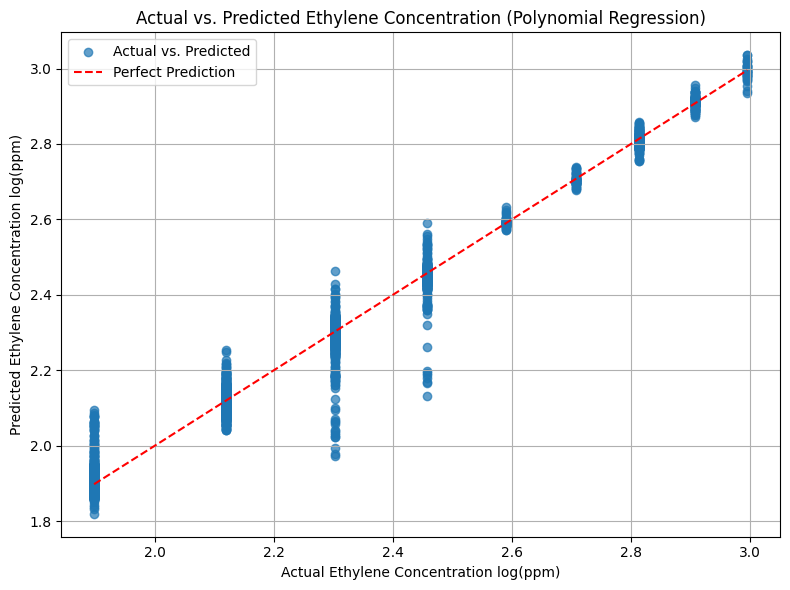

In [4]:
y_actual = Y_test.values.ravel()  # Flattening the array for plotting
y_predicted = yhat

#scatter plot with informative labels and title
plt.figure(figsize=(8, 6)) 
plt.scatter(y_actual, y_predicted, alpha=0.7, label='Actual vs. Predicted')
plt.xlabel('Actual Ethylene Concentration log(ppm)')
plt.ylabel('Predicted Ethylene Concentration log(ppm)')
plt.title('Actual vs. Predicted Ethylene Concentration (Polynomial Regression)')
plt.grid(True)

# diagonal line for perfect prediction
perfect_line = plt.plot([min(y_actual), max(y_actual)], [min(y_actual), max(y_actual)], color='red', linestyle='--', label='Perfect Prediction')

#legend for clarity
plt.legend()

plt.tight_layout() 

plt.show()

In [5]:
#Finding Mean Square Error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

m = mean_squared_error(Y_test, yhat)
print(f"Mean Square Error: {m}")
r2 = r2_score(Y_test, yhat)
r2_error = 1 - r2
print(f"R-squared : {r2}")
print("R-squared Error:", r2_error)

Mean Square Error: 0.0010708144485919952
R-squared : 0.9852330720645882
R-squared Error: 0.014766927935411789


In [6]:
#Exporting the model to pkl
import joblib
with open("methane_polynomial.pkl","wb") as f:
    joblib.dump(pipe,f)

In [7]:
#Loading the model
model=joblib.load(r"methane_polynomial.pkl")
model

,steps,"[('scale', ...), ('polynomial', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'


In [8]:
#Testing the model
import math
import numpy as np

sample_readings = np.array(X_test.iloc[8]).reshape(1,-1)

predicted = model.predict(sample_readings)
actual = np.array(Y_test.iloc[8]).reshape(1,-1)

print(f"Actual Value : {math.exp(actual[0][0])} ppm")
print(f"Predicted Value : {math.exp(predicted[0][0])} ppm")

Actual Value : 10.000000000000002 ppm
Predicted Value : 9.977799484554955 ppm


C:\Users\Manjunadh\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
